In [1]:
# 📌 Bagian 1: Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg
from pygimli.physics.ves import VESManager
import ipywidgets as widgets
from IPython.display import display, clear_output

# Set tampilan font
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 10

✅ Grafik berhasil disimpan sebagai 'Grafik Data Observasi GL-044.png'.


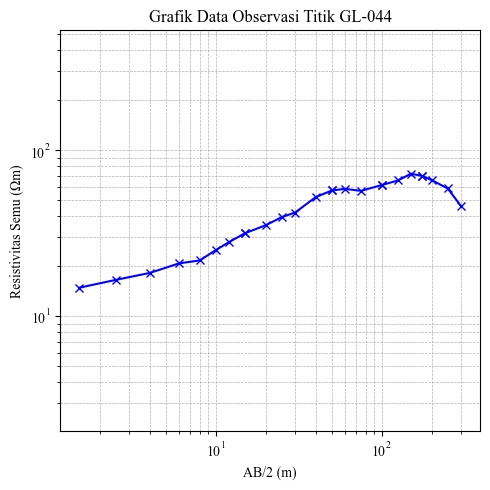

,AB/2 (m),MN/2 (m),ρ app koreksi shifting
0,1.5,0.5,14.852610
1,2.5,0.5,16.578300
2,4.0,0.5,18.240324
3,6.0,0.5,20.834738
4,8.0,0.5,21.695022


In [2]:
# 📌 Bagian 2: Load Data
data = pd.read_excel("GL-044.xlsx")

ab2 = data["AB/2 (m)"].values
mn2 = data["MN/2 (m)"].values
rhoa = data["ρ app koreksi shifting"].values

# Menampilkan data
plt.figure(figsize=(5, 5), dpi=100)
plt.loglog(ab2, rhoa, "x-", color="blue")
plt.xlabel("AB/2 (m)")
plt.ylabel("Resistivitas Semu (Ωm)")
plt.title("Grafik Data Observasi Titik GL-044")
plt.axis('equal')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()

# 🖼️ Save the plot
plt.savefig("Grafik Data Observasi GL-044.png", dpi=300)
print("✅ Grafik berhasil disimpan sebagai 'Grafik Data Observasi GL-044.png'.")

# 👀 Show the plot on screen
plt.show()

# 🧹 Hapus duplikat AB/2 (dan pastikan mn2 dan rhoa ikut)
_, unique_indices = np.unique(ab2, return_index=True)
ab2 = ab2[unique_indices]
mn2 = mn2[unique_indices]
rhoa = rhoa[unique_indices]

# Tampilkan beberapa data awal
data.head()

In [7]:
# 📌 Bagian 3: Inversi VES
n_layers = 7
lam = 100
lambda_factor = 0.9
max_iter = 100
noise_level = 0.05
err = noise_level * np.ones_like(rhoa)

# Model awal dengan 13 parameter
initial_model = [1.5, 6.5, 22, 20, 10, 90, 14.85261017, 21.69502212, 42.150389, 57.28547077, 58.59335823, 72.28750265, 46.17230199]

ves_manager = VESManager()
inv_result = ves_manager.invert(data=rhoa, err=err, ab2=ab2, mn2=mn2,
                                nLayers=n_layers, lam=lam, lambdaFactor=lambda_factor,
                                startModel=initial_model, maxIter=max_iter, verbose=True, blockyModel=True)

predicted_rhoa = ves_manager.simulate(inv_result, ab2=ab2, mn2=mn2)

09/01/26 - 11:10:29 - pyGIMLi - INFO - Starting inversion.
09/01/26 - 11:10:29 - pyGIMLi - WARNING - Multiprocess Jacobian currently unavailable for Win32 and Mac.


fop: <pygimli.physics.ves.vesModelling.VESModelling object at 0x00000203EECEBA60>
Data transformation: Logarithmic transform
Model transformation (cumulative):
	 0 Logarithmic LU transform, lower bound 0.1, upper bound 150.0
	 1 Logarithmic LU transform, lower bound 0.0, upper bound 0.0
min/max (data): 14.85/72.29
min/max (error): 5%/5%
min/max (start model): 1.5/90
--------------------------------------------------------------------------------


09/01/26 - 11:10:29 - pyGIMLi - WARNING - Multiprocess Jacobian currently unavailable for Win32 and Mac.


inv.iter 0 ... chi² =   20.00
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =    2.09 (dPhi = 89.57%) lam: 100.0
--------------------------------------------------------------------------------
inv.iter 2 ... 

09/01/26 - 11:10:29 - pyGIMLi - WARNING - Multiprocess Jacobian currently unavailable for Win32 and Mac.


...

chi² =    0.53 (dPhi = 1.27%) lam: 8.0
--------------------------------------------------------------------------------
inv.iter 26 ... 

09/01/26 - 11:10:37 - pyGIMLi - WARNING - Multiprocess Jacobian currently unavailable for Win32 and Mac.


chi² =    0.53 (dPhi = 1.12%) lam: 7.2
--------------------------------------------------------------------------------
inv.iter 27 ... 

09/01/26 - 11:10:37 - pyGIMLi - WARNING - Multiprocess Jacobian currently unavailable for Win32 and Mac.


chi² =    0.52 (dPhi = 1.01%) lam: 6.5
--------------------------------------------------------------------------------
chi² =    0.52 (dPhi = 0.89%) lam: 5.8
################################################################################
#                Abort criterion reached: dPhi = 0.89 (< 1.0%)                 #
################################################################################


✅ Grafik berhasil disimpan sebagai 'Grafik Data Observasi vs Data Kalkulasi GL-044.png'.


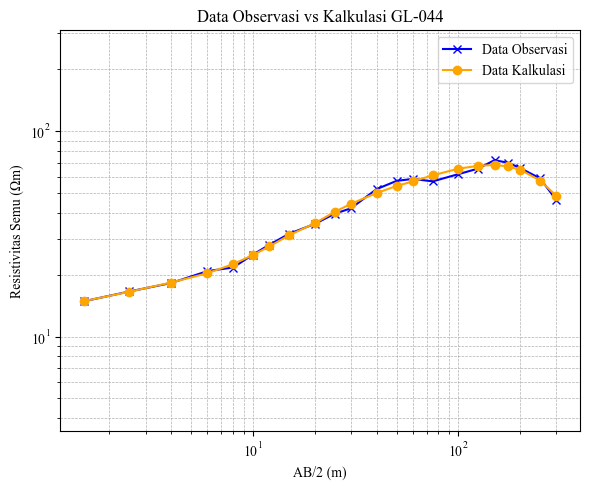

In [8]:
# 📌 Bagian 4a: Plot Observasi vs Kalkulasi
fig, ax1 = plt.subplots(figsize=(6, 5), dpi=100)
ax1.loglog(ab2, rhoa, "x-", label="Data Observasi", color="blue")
ax1.loglog(ab2, predicted_rhoa, "o-", label="Data Kalkulasi", color="orange")
ax1.set_title("Data Observasi vs Kalkulasi GL-044")
ax1.set_xlabel("AB/2 (m)")
ax1.set_ylabel("Resistivitas Semu (Ωm)")
ax1.grid(True, which="both", ls="--", linewidth=0.5)
ax1.axis('equal')
ax1.legend()
plt.tight_layout()

# 🖼️ Save the plot
plt.savefig("Grafik Data Observasi vs Data Kalkulasi GL-044.png", dpi=300)
print("✅ Grafik berhasil disimpan sebagai 'Grafik Data Observasi vs Data Kalkulasi GL-044.png'.")

# 👀 Show the plot on screen
plt.show()

✅ Tabel error berhasil disimpan sebagai file Excel: Tabel Error Data Observasi vs Data Kalkulasi GL-044.xlsx


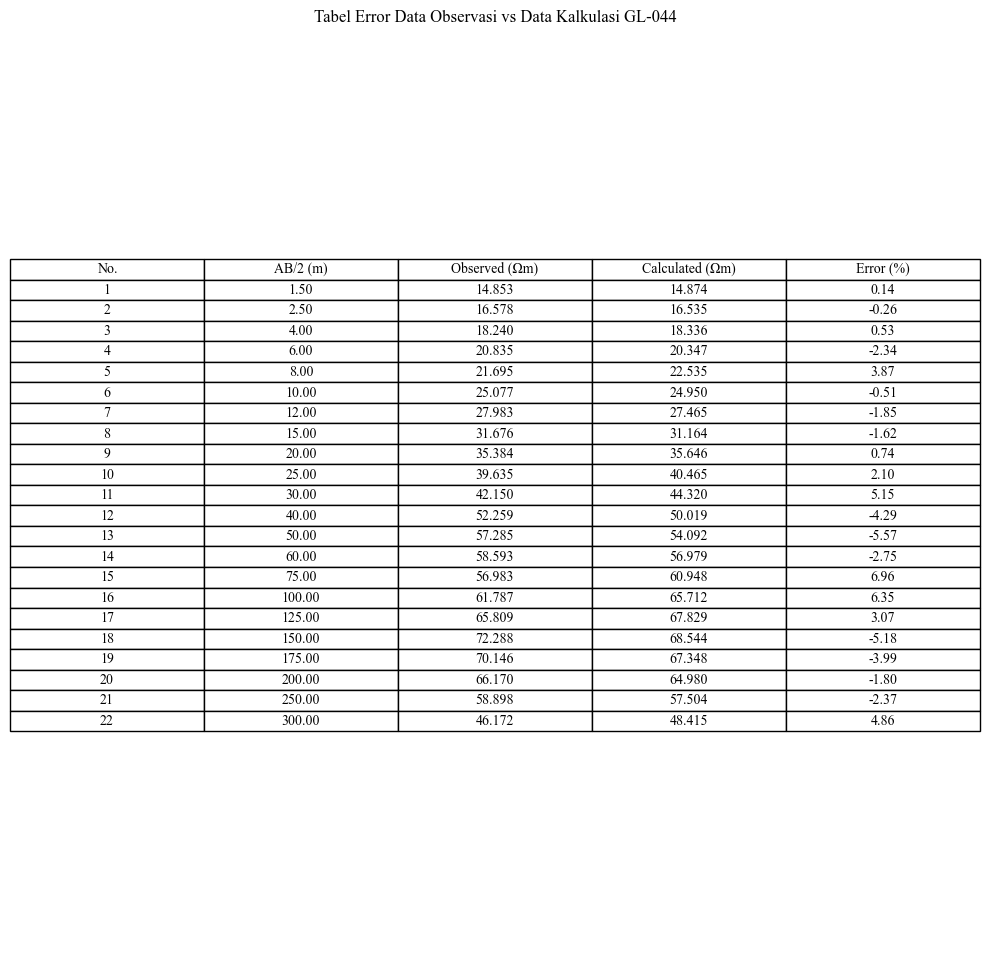

In [5]:
# 📌 Bagian 4b: Tabel Error
error_percent = ((predicted_rhoa - rhoa) / rhoa) * 100
table_data = [[i + 1, f"{ab2[i]:.2f}", f"{rhoa[i]:.3f}", f"{predicted_rhoa[i]:.3f}", f"{error_percent[i]:.2f}"]
              for i in range(len(ab2))]

col_labels = ["No.", "AB/2 (m)", "Observed (Ωm)", "Calculated (Ωm)", "Error (%)"]

fig2, ax2 = plt.subplots(figsize=(10, len(ab2) * 0.4 + 1), dpi=100)
ax2.axis("off")
table = ax2.table(cellText=table_data,
                  colLabels=col_labels,
                  loc="center",
                  cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1)

plt.title("Tabel Error Data Observasi vs Data Kalkulasi GL-044")
plt.tight_layout()

# ✅ Simpan sebagai gambar PNG
plt.savefig("Tabel Error Data Observasi vs Data Kalkulasi GL-044.png", bbox_inches='tight', dpi=300)

# Buat DataFrame dari data tabel
df_error = pd.DataFrame(table_data, columns=col_labels)

# Simpan ke file Excel
excel_filename = "Tabel Error Data Observasi vs Data Kalkulasi GL-044.xlsx"
df_error.to_excel(excel_filename, index=False, engine='openpyxl')

print(f"✅ Tabel error berhasil disimpan sebagai file Excel: {excel_filename}")

plt.show()

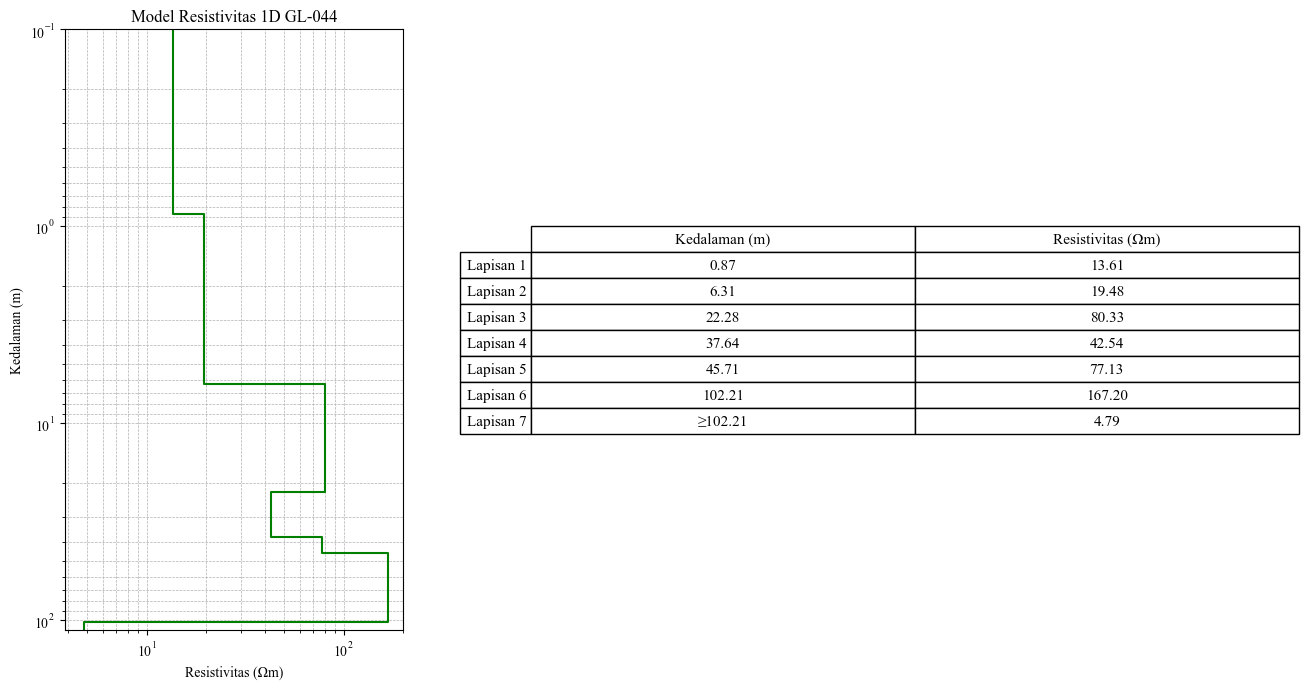

In [6]:
# 📌 Bagian 4c: Model Resistivitas 1D + Tabel Lapisan (Berdampingan)
# Data model dari hasil inversi
model_array = inv_result
thicknesses = model_array[:n_layers - 1]
resistivities = model_array[n_layers - 1:]

# Hitung kedalaman bawah setiap lapisan
depth_bottoms = np.cumsum(thicknesses)
depth_tops = np.concatenate(([0.1], depth_bottoms))  # mulai dari 0.05 m
depth_bottoms = np.concatenate((depth_bottoms, [depth_bottoms[-1] + 10]))

# Buat kedalaman dan resistivitas untuk plot step
depths_plot = np.repeat(depth_tops, 2)[1:]
depths_plot = np.append(depths_plot, depth_bottoms[-1])
resistivities_plot = np.repeat(resistivities, 2)

# Tabel data
layer_labels = [f"Lapisan {i+1}" for i in range(n_layers)]
table_data_model = []
for i in range(n_layers):
    depth = f"{depth_bottoms[i]:.2f}" if i < n_layers - 1 else f"≥{depth_bottoms[-2]:.2f}"
    rho = f"{resistivities[i]:.2f}"
    table_data_model.append([depth, rho])

# Gambar
fig3, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 7), dpi=100)

# Plot resistivitas 1D
ax3.plot(resistivities_plot, depths_plot, color="green")
ax3.set_xscale('log')
ax3.set_yscale('log')

# Batas sumbu
xmin = min(resistivities_plot) * 0.8
xmax = max(resistivities_plot) * 1.2
ymin = 0.1
ymax = depths_plot[-1]

ax3.set_xlim(xmin, xmax)
ax3.set_ylim(ymin, ymax)
ax3.invert_yaxis()  # untuk arah kedalaman dari atas ke bawah

# ✅ Atur aspect ratio agar sumbu X dan Y proporsional (berdasarkan skala log)
log_xrange = np.log10(xmax) - np.log10(xmin)
log_yrange = np.log10(ymax) - np.log10(ymin)
ax3.set_box_aspect(log_yrange / log_xrange)

# Label dan grid
ax3.set_title("Model Resistivitas 1D GL-044")
ax3.set_xlabel("Resistivitas (Ωm)")
ax3.set_ylabel("Kedalaman (m)")
ax3.grid(True, which='both', linestyle='--', linewidth=0.5)

# Tabel lapisan
ax4.axis("off")
table = ax4.table(cellText=table_data_model,
                  colLabels=["Kedalaman (m)", "Resistivitas (Ωm)"],
                  rowLabels=layer_labels,
                  loc="center",
                  cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.4)

plt.tight_layout()
plt.savefig("Model Resistivitas 1D GL-044.png", dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# 📌 Bagian 5: Evaluasi RRMSE
relative_errors = (predicted_rhoa - rhoa) / rhoa
rrmse = np.sqrt(np.mean(relative_errors**2)) * 100

if rrmse < 10:
    quality = "✅ Good fit"
elif 10 <= rrmse <= 20:
    quality = "⚠️ Moderate fit"
else:
    quality = "❌ Poor fit"

print(f"\nInversion Result (Resistivity Model):\n{inv_result}")
print(f"\nRRMSE: {rrmse:.2f}% - {quality}")



Inversion Result (Resistivity Model):
13 [0.8653077954812715, 5.4426248324779625, 15.971487979956992, 15.358337367301848, 8.075356008739384, 56.49599013060146, 13.610923084075905, 19.477003753763267, 80.33001289186187, 42.536635126337075, 77.13407933358516, 167.19632721011152, 4.7932358621067275]

RRMSE: 3.62% - ✅ Good fit


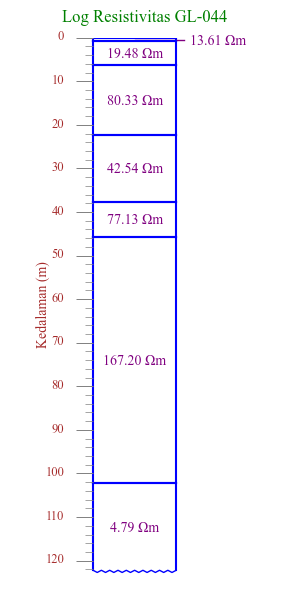

In [8]:
# 📌 Bagian 6: Membuat Log Resistivitas
fig, ax = plt.subplots(figsize=(3, 6), dpi=100)

occupied_positions = []  # Simpan posisi label luar
min_spacing = 2.5        # Jarak minimum antar label luar (dalam meter)

# --- Gambar Layer ---
top = 0
for i in range(n_layers):
    bottom = depth_bottoms[i] if i < n_layers - 1 else depth_bottoms[-1] + 10

    # Garis kotak biru
    ax.plot([0.4, 0.4], [top, bottom], color='blue')   # kiri
    ax.plot([0.6, 0.6], [top, bottom], color='blue')   # kanan
    ax.plot([0.4, 0.6], [top, top], color='blue')      # atas
    if i < n_layers - 1:
        ax.plot([0.4, 0.6], [bottom, bottom], color='blue')  # bawah

    # --- Label Resistivitas ---
    center_y = (top + bottom) / 2
    label_text = f"{resistivities[i]:.2f} Ωm"
    if bottom - top < 5:
        # Pastikan label luar tidak saling berhimpitan
        adjusted_y = center_y
        while any(abs(adjusted_y - oy) < min_spacing for oy in occupied_positions):
            adjusted_y += min_spacing  # Geser ke bawah

        occupied_positions.append(adjusted_y)

        # Buat titik akhir garis sedikit lebih rendah agar teks tidak nempel garis
        line_end_y = adjusted_y - 1  # atur jarak antara garis dan teks

        # Tampilkan teks dan garis penghubung
        ax.text(0.7, adjusted_y, label_text,
                color='purple', fontsize=10, ha='center', va='center')
        ax.plot([0.5, 0.62], [center_y, adjusted_y],
                color='purple', linewidth=1)
    else:
        ax.text(0.5, center_y, label_text,
                color='purple', fontsize=10, ha='center', va='center')

    top = bottom

# --- Zig-Zag di Bawah Blok Terakhir ---
zigzag_start = 0.4
zigzag_end = 0.6
zigzag_depth = depth_bottoms[-1] + 10
zigzag_height = 0.5
num_zigs = 10

x_vals = []
y_vals = []

x_step = (zigzag_end - zigzag_start) / (num_zigs * 2)

for i in range(num_zigs * 2 + 1):
    x = zigzag_start + i * x_step
    y = zigzag_depth + (zigzag_height if i % 2 == 1 else 0)
    x_vals.append(x)
    y_vals.append(y)

ax.plot(x_vals, y_vals, color='blue', linewidth=1)

# --- Skala Kedalaman dan Strip ---
depth_max = depth_bottoms[-1] + 10

for d in range(0, int(depth_max) + 1, 2):
    if d % 10 == 0:
        ax.hlines(d, 0.36, 0.4, color='gray', linewidth=0.7)
        ax.text(0.33, d - 0.3, f"{d}", ha='right', va='center', fontsize=9, color='brown')
    else:
        ax.hlines(d, 0.38, 0.4, color='gray', linestyle='-', linewidth=0.5)

# --- Label Vertikal "Kedalaman (m)" ---
ax.text(0.28, depth_max / 2, "Kedalaman (m)", fontsize=10,
        rotation=90, va='center', ha='center', color='brown')

# --- Styling ---
ax.set_xlim(0.2, 0.85)
ax.set_ylim(depth_max + 2, 0)
ax.axis('off')

plt.title("Log Resistivitas GL-044", fontsize=12, color='green', pad=12)
plt.tight_layout()

# ✅ Simpan sebagai gambar PNG
plt.savefig("Log Resistivitas GL-044.png", bbox_inches='tight', dpi=300)

plt.show()

In [9]:
# 📌 Bagian 7: Menyimpan hasil log ke excel
df_lapisan = pd.DataFrame(table_data_model, columns=["Kedalaman (m)", "Resistivitas (Ωm)"])
df_lapisan.insert(0, "Lapisan", layer_labels)
df_lapisan.to_csv("Tabel Model Resistivitas GL-044.csv", index=False)